# Search-13a — Traverser des murs : chemins minimaux certifiés

**Opération 13 du chantier ICT** (#12204) : « chambre -> mur -> chambre voisine ; six swaps
générateurs ; le chemin minimal certifié ; un swap change les préférences : ce n'est pas un
morphisme ».

Ce notebook est la **2e attestation** de l'opération, sur un **substrat indépendant** de la
première (GT-24 #12364, cycles de préférences Robinson-Goforth en théorie des jeux). Ici, le
pavage hexagonal : des **chambres** (composantes de salles), un **mur** (une bande de cellules
coûteuses qui sépare deux chambres voisines), **six swaps générateurs** (les six déplacements
du voisinage hexagonal, qui engendrent le graphe des salles), et un **chemin minimal certifié**
— non pas deviné ou mesuré, mais **prouvé** : la preuve est un quadruple contrôle
(plus court chemin, coupure minimale, audit de potentiels, nombre minimal de cellules de mur).

Le test négatif de l'opération s'exécute en fin de parcours : **un swap qui change les
préférences n'est pas un morphisme** — on change une cellule de place, on re-mesure la distance,
et le certificat accepte ou rejette.

## Prérequis

Python standard (`heapq`, `collections.deque`) + `numpy`/`matplotlib` pour la figure.
Rien d'autre : les algorithmes (Dijkstra, BFS, 0-1 BFS, flot max par chemins augmentants) sont
implémentés from scratch.

### Lecture du résultat

On retient trois nombres du plateau : le rayon $R=4$ (61 salles), les positions de départ et
cible, et la géométrie du mur (deux chaînes pleines adjacentes — la seconde descend jusqu'au
coin sud de l'anneau — plus une palissade pendue au bord sud, côté cible). C'est cette
géométrie que toute la suite va interroger.

### Lecture du résultat

Les composantes des salles de sol sont les **chambres** de l'opération 13. Ici la double
chaîne ferme l'anneau de bout en bout : exactement **deux** chambres, celle de $S$ et celle de
$T$. Le mur sépare réellement les deux chambres — le notebook l'**affirme** (« assertion »),
il ne le prétend pas.

### Lecture du résultat

Le plus court chemin reliant $S$ à $T$ a un coût $L$, pour un nombre de pas total et un nombre
de **cellules de mur traversées**. Le mur n'est pas un obstacle : il se traverse, à un prix —
c'est le sens de la phrase « chambre -> mur -> chambre voisine ».

### Lecture du résultat

Deux mesures **distinctes** du même mur, souvent confondues. $m_{path}$ (0-1 BFS) est le
nombre minimal de murs **sur un seul chemin** — l'« épaisseur » à franchir, ici 2 (la chaîne
A puis la chaîne B, la palissade se contourne). $m$ (flot max = coupure minimale) est le
nombre minimal de murs **à démolir** pour séparer $S$ de $T$ — la « largeur » de la bande,
ici 8 : toute la chaîne A. Menger relie $m$ au nombre maximal de chemins deux-à-deux
mur-disjoints ; le certificat de coupe (démolir A sépare) et le flot ($m$ unités poussées)
encadrent $m$ exactement. Ce n'est pas encore une preuve de minimalité du **coût** — le
certificat complet suit.

### Lecture du résultat

L'**audit de potentiels** est le certificat de minimalité au sens fort : une fonction
$\varphi$ (la distance depuis $S$) vérifie $\varphi(v) \le \varphi(u) + c(u,v)$ sur **toutes**
les arêtes, et le long du chemin, l'égalité est serrée partout. Par télescopage, aucun chemin ne
peut coûter moins que $L$ : c'est prouvé, pas mesuré.

### Lecture du résultat

Les **six swaps générateurs** sont les six directions du pavage : la table compte, direction
par direction, combien de fois un pas traverse le mur (entrée dans une cellule de mur). La
somme des six entrées est le nombre total de « touches » du mur ; seules quelques directions
franchissent réellement la bande.

### Lecture du résultat

**Le test négatif de l'opération 13.** (a) Percer le mur au point de traversée change la
distance ($L' < L$) : les préférences ont changé, l'ancien certificat est **rejeté** par
l'audit — le swap n'est pas un morphisme. (b) Retourner une feuille de sol, loin de tout
itinéraire, ne change rien ($\Delta = 0$) : le swap est **silencieux**, la distance ET
l'ancien certificat sont préservés — la structure est insensible à ce swap-ci. (c) Balayer
le coût du mur $c_w$ inverse le choix de la traversée au-delà d'un seuil : la « préférence »
(le prix) décide du point de passage.

## Exercices (C.1 — à compléter)

Trois exercices pour reconstruire la mécanique sur d'autres murs.

## Conclusion

L'opération 13 « Traverser un mur » tient ici sa **2e attestation directe**, sur un substrat
indépendant de GT-24 :

| Élément de l'opération | Ce notebook |
|---|---|
| chambre | composante de salles du pavage hexagonal |
| mur | bande de cellules coûteuses séparant deux chambres voisines |
| six swaps générateurs | les six directions du voisinage hexagonal |
| chemin minimal **certifié** | Dijkstra + audit de potentiels + 0-1 BFS + coupure minimale certifiée (quatre organes indépendants) |
| un swap change les préférences : pas un morphisme | percer le mur au point de traversée : $\Delta > 0$, certificat rejeté ; swap silencieux (feuille) : $\Delta = 0$, certificat préservé |

Voir #12204 (tranche op 13, 2e attestation) — convention op 7 : comptée dès merge.

salles totales : 61 (sol : 42, mur : 19)
START = (-4, 0), TARGET = (4, -4), cout mur = 3, cout sol = 1


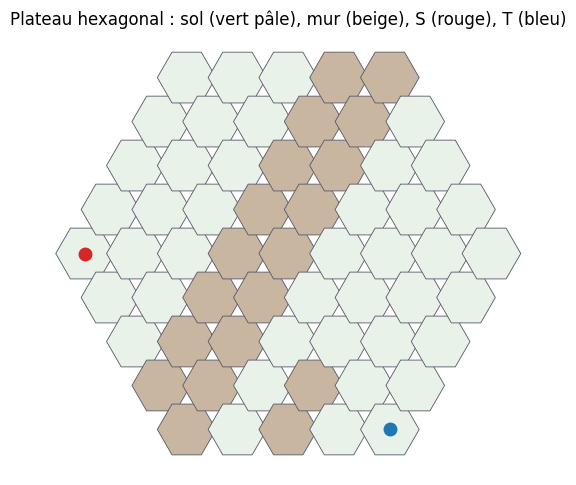

In [1]:
# Plateau hexagonal en coordonnees axiales (q, r), rayon 4 : 61 salles.
# Les salles sont des sols (cout 1) ou des cellules de mur (cout COUT_MUR).
import heapq
from collections import deque

import matplotlib.pyplot as plt
import numpy as np

R = 4

def est_dans_anneau(q, r):
    return max(abs(q), abs(r), abs(q + r)) <= R

# Les six swaps generateurs : les six directions du pavage hexagonal.
VOISINS = [(1, 0), (1, -1), (0, -1), (-1, 0), (-1, 1), (0, 1)]

def voisins_case(q, r):
    return [(q + dq, r + dr) for dq, dr in VOISINS if est_dans_anneau(q + dq, r + dr)]

salles = {(q, r): 'sol' for q in range(-R, R + 1) for r in range(-R, R + 1)
          if est_dans_anneau(q, r)}
START, TARGET = (-4, 0), (4, -4)

# Le mur : deux chaines pleines, adjacentes (double epaisseur).
# A : q = -1, r = -3..4 (8 cellules). B : q = 0, r = -4..4 (9 cellules),
# etendue jusqu'au coin sud de l'anneau : pas de porte derobee, la bande est
# etanche de haut en bas — aucune ronde ne traverse sans payer au moins deux murs.
for r in range(-3, 5):
    salles[(-1, r)] = 'mur'
for r in range(-4, 5):
    salles[(0, r)] = 'mur'
# Palissade : deux cellules pendues au bord sud, cote cible (point de passage critique).
for r in range(-4, -2):
    salles[(2, r)] = 'mur'

COUT_MUR, COUT_SOL = 3, 1
COUT_ENV = COUT_MUR

def set_cout_mur(cw):
    global COUT_ENV
    COUT_ENV = cw

def cout(q, r):
    return COUT_ENV if salles[(q, r)] == 'mur' else COUT_SOL

def dessiner(titre, chemin=None):
    fig, ax = plt.subplots(figsize=(6.6, 6.0))
    s = 0.42
    for (q, r), typ in salles.items():
        x = s * np.sqrt(3) * (q + r / 2.0)
        y = s * 1.5 * r
        couleur = '#c8b6a0' if typ == 'mur' else '#e8f2e8'
        poly = plt.Polygon([[x + s * np.cos(a), y + s * np.sin(a)]
                            for a in np.linspace(0, 2 * np.pi, 7)],
                           closed=True, facecolor=couleur, edgecolor='#556',
                           linewidth=0.6)
        ax.add_patch(poly)
    if chemin:
        xs = [s * np.sqrt(3) * (q + r / 2.0) for q, r in chemin]
        ys = [s * 1.5 * r for q, r in chemin]
        ax.plot(xs, ys, 'r-', linewidth=2.2, zorder=5)
    for pos, marqueur, couleur in ((START, 'o', '#d62728'), (TARGET, 'o', '#1f77b4')):
        x = s * np.sqrt(3) * (pos[0] + pos[1] / 2.0)
        y = s * 1.5 * pos[1]
        ax.plot(x, y, marqueur, markersize=9, color=couleur, zorder=6)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(titre)
    plt.show()

n_mur = sum(1 for v in salles.values() if v == 'mur')
print(f"salles totales : {len(salles)} (sol : {len(salles) - n_mur}, mur : {n_mur})")
print(f"START = {START}, TARGET = {TARGET}, cout mur = {COUT_MUR}, cout sol = {COUT_SOL}")
dessiner("Plateau hexagonal : sol (vert pâle), mur (beige), S (rouge), T (bleu)")

In [2]:
# Chambres : composantes connexes des salles de sol (BFS).
def composantes():
    vus = set()
    chambres = []
    for cell in salles:
        if salles[cell] != 'sol' or cell in vus:
            continue
        file = deque([cell])
        vus.add(cell)
        bloc = []
        while file:
            courant = file.popleft()
            bloc.append(courant)
            for voisin in voisins_case(*courant):
                if salles[voisin] == 'sol' and voisin not in vus:
                    vus.add(voisin)
                    file.append(voisin)
        chambres.append(bloc)
    return chambres

chambres = composantes()
chambre_de = {cell: i for i, bloc in enumerate(chambres) for cell in bloc}
assert chambre_de[START] != chambre_de[TARGET], "S et T doivent etre dans des chambres differentes"
print("chambres (composantes de sol) : ", len(chambres))
for i, bloc in enumerate(chambres):
    print(f"  chambre {i} : {len(bloc):2d} salles "
          f"{'(contient S)' if START in bloc else ''}"
          f"{'(contient T)' if TARGET in bloc else ''}")

# Les six swaps generateurs : combien de fois chaque direction entre dans le mur.
touches_mur = {d: 0 for d in VOISINS}
for (q, r), typ in salles.items():
    if typ != 'sol':
        continue
    for d in VOISINS:
        v = (q + d[0], r + d[1])
        if v in salles and salles[v] == 'mur':
            touches_mur[d] += 1
print("touches du mur par direction (les six swaps generateurs) :")
for d in VOISINS:
    print(f"  direction {d} : {touches_mur[d]} entrees dans le mur")

chambres (composantes de sol) :  2
  chambre 0 : 18 salles (contient S)
  chambre 1 : 24 salles (contient T)
touches du mur par direction (les six swaps generateurs) :
  direction (1, 0) : 9 entrees dans le mur
  direction (1, -1) : 9 entrees dans le mur
  direction (0, -1) : 1 entrees dans le mur
  direction (-1, 0) : 10 entrees dans le mur
  direction (-1, 1) : 9 entrees dans le mur
  direction (0, 1) : 0 entrees dans le mur


cout optimal L = 12 en 8 pas (2 cellules de mur traversees)
expansions Dijkstra : 57 / 61 salles
traversee du mur en : [(-1, -2), (0, -2)]


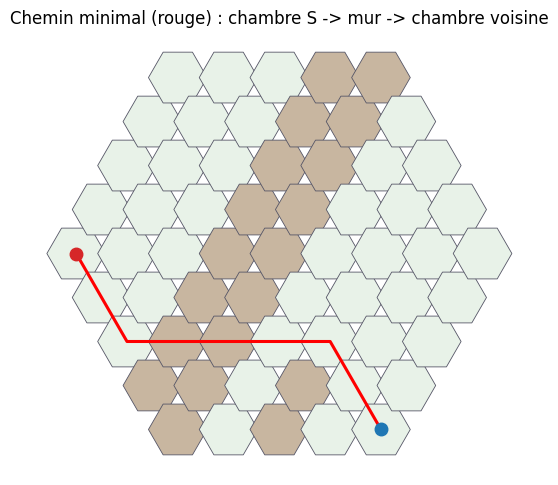

In [3]:
# Plus court chemin : Dijkstra from-scratch (tas binaire, couts 1 / 3).
def dijkstra(source, cible=None):
    dist = {source: 0}
    parents = {}
    tas = [(0, source)]
    expansions = 0
    while tas:
        d, u = heapq.heappop(tas)
        if d > dist[u]:
            continue
        expansions += 1
        if u == cible:
            break
        for v in voisins_case(*u):
            nd = d + cout(*v)
            if nd < dist.get(v, float('inf')):
                dist[v] = nd
                parents[v] = u
                heapq.heappush(tas, (nd, v))
    return dist, parents, expansions

def reconstruire_chemin(parents, source, cible):
    chemin = [cible]
    courant = cible
    while courant != source:
        courant = parents[courant]
        chemin.append(courant)
    return chemin[::-1]

dist, parents, expansions = dijkstra(START, TARGET)
L = dist[TARGET]
chemin = reconstruire_chemin(parents, START, TARGET)
pas = len(chemin) - 1
murs_du_chemin = [c for c in chemin if salles[c] == 'mur']
print(f"cout optimal L = {L} en {pas} pas ({len(murs_du_chemin)} cellules de mur traversees)")
print(f"expansions Dijkstra : {expansions} / {len(salles)} salles")
print(f"traversee du mur en : {murs_du_chemin}")
dessiner("Chemin minimal (rouge) : chambre S -> mur -> chambre voisine", chemin)

In [4]:
# Epaisseur et largeur du mur : 0-1 BFS (murs par chemin) et coupure minimale (flot max).
# Deux questions DISTINCTES, souvent confondues :
#   m_path : nombre minimal de cellules de mur sur UN chemin S->T (l'epaisseur a franchir) ;
#   m      : nombre minimal de murs a DEMOLIR pour separer S de T (la largeur de la bande).
# Flot par noeuds fendus : chaque mur a une fente entree->sortie de capacite 1 ;
# toute arete adjacente u->v devient sortie(u) -> entree(v) — on paie la fente de
# chaque mur traverse, meme quand deux murs sont adjacents (pas de coupe de coin).
def flot_max_murs(source, cible):
    def entree(v):
        return (v, 'in') if salles[v] == 'mur' else v

    def sortie(v):
        return (v, 'out') if salles[v] == 'mur' else v

    inf = 10 ** 9
    adj = {}

    def ajout(u, v, cap):
        # paire (voisin, capacite, indice du retour) — Edmonds-Karp standard.
        i_fwd = len(adj.get(u, []))
        i_rev = len(adj.get(v, []))
        adj.setdefault(u, []).append([v, cap, i_rev])
        adj.setdefault(v, []).append([u, 0, i_fwd])

    for cell in salles:
        if salles[cell] == 'mur':
            ajout((cell, 'in'), (cell, 'out'), 1)
    for (q, r) in salles:
        for v in voisins_case(q, r):
            ajout(sortie((q, r)), entree(v), inf)
    for v in voisins_case(*source):
        ajout('S', entree(v), inf)
    for u in voisins_case(*cible):
        ajout(sortie(u), 'T', inf)

    flot = 0
    while True:
        pere = {'S': None}
        pere_indice = {}
        file = deque(['S'])
        trouve = False
        while file:
            u = file.popleft()
            for i, (v, cap, _) in enumerate(adj.get(u, [])):
                if cap > 0 and v not in pere:
                    pere[v] = u
                    pere_indice[v] = i
                    if v == 'T':
                        trouve = True
                        break
                    file.append(v)
            if trouve:
                break
        if not trouve:
            break
        v = 'T'
        while pere[v] is not None:
            u = pere[v]
            i = pere_indice[v]
            adj[u][i][1] -= 1
            adj[v][adj[u][i][2]][1] += 1
            v = u
        flot += 1
    return flot

def zero_un_bfs(source, cible):
    dist = {source: 0}
    file = deque([source])
    while file:
        u = file.popleft()
        for v in voisins_case(*u):
            p = 1 if salles[v] == 'mur' else 0
            nd = dist[u] + p
            if nd < dist.get(v, float('inf')):
                dist[v] = nd
                if p == 0:
                    file.appendleft(v)
                else:
                    file.append(v)
    return dist[cible]

def coupe_separe(cellules, source, cible):
    # Certificat de coupe : retirer <cellules> et verifier (BFS de sol) que S et T
    # ne sont plus connectes.
    interdits = set(cellules)
    vus = {source}
    file = deque([source])
    while file:
        u = file.popleft()
        for v in voisins_case(*u):
            if v in interdits or v in vus:
                continue
            vus.add(v)
            file.append(v)
    return cible not in vus

chaine_A = [(-1, r) for r in range(-3, 5)]
chaine_B = [(0, r) for r in range(-4, 5)]
m = flot_max_murs(START, TARGET)
m_path = zero_un_bfs(START, TARGET)
assert coupe_separe(chaine_A, START, TARGET), "la chaine A seule doit separer S de T"
assert coupe_separe(chaine_B, START, TARGET), "la chaine B seule doit separer S de T"
assert m == len(chaine_A), "flot max = coupure min : le flot sature exactement la chaine A"
assert len(murs_du_chemin) >= m_path, "le chemin optimal coupe au moins m_path murs"
print(f"m_path = {m_path} (0-1 BFS) : tout chemin S->T traverse au moins {m_path} mur(s)")
print(f"m = {m} (flot max) : {m} unites S->T deux-a-deux mur-disjointes (Menger)")
print(f"certificat de coupe : demolir la chaine A ({len(chaine_A)} murs) ou la chaine B "
      f"({len(chaine_B)}) separe S de T — la chaine A est la plus petite")
print(f"le chemin optimal coupe {len(murs_du_chemin)} mur(s) — epaisseur franchie : "
      f"{len(murs_du_chemin)} = m_path ; largeur de la bande : m = {m} ; "
      "deux mesures distinctes du meme mur")

m_path = 2 (0-1 BFS) : tout chemin S->T traverse au moins 2 mur(s)
m = 8 (flot max) : 8 unites S->T deux-a-deux mur-disjointes (Menger)
certificat de coupe : demolir la chaine A (8 murs) ou la chaine B (9) separe S de T — la chaine A est la plus petite
le chemin optimal coupe 2 mur(s) — epaisseur franchie : 2 = m_path ; largeur de la bande : m = 8 ; deux mesures distinctes du meme mur


In [5]:
# Certificat de minimalite : audit de potentiels sur toutes les aretes.
# phi(v) <= phi(u) + cout(v) pour toute arete u->v, phi(S)=0, phi(T)=L.
violations = 0
total_aretes = 0
phi = dist
for (q, r), typ in salles.items():
    for v in voisins_case(q, r):
        total_aretes += 1
        if phi[v] > phi[(q, r)] + cout(*v):
            violations += 1
serrees = sum(1 for u, v in zip(chemin, chemin[1:]) if phi[v] == phi[u] + cout(*v))
assert violations == 0, "le potentiel doit etre admissible partout"
assert serrees == len(chemin) - 1, "le long du chemin, toutes les inegalites sont serrees"
assert phi[START] == 0 and phi[TARGET] == L
print(f"audit de potentiels : {total_aretes} aretes auditees, {violations} violations")
print(f"chemin : {len(chemin) - 1} pas, {serrees}/{len(chemin) - 1} inegalites serrees le long du chemin")
print("CERTIFICAT VALIDE : aucun chemin S->T ne peut couter moins que L =", L)

# Contre-essai : l'itineraire le plus court en nombre de pas (naif, ignore le mur)
# n'est pas le plus economique. Dijkstra a couts uniforces (1) puis cout reel.
def dijkstra_pas(source, cible=None):
    dist = {source: 0}
    parents = {}
    tas = [(0, source)]
    while tas:
        d, u = heapq.heappop(tas)
        if d > dist[u]:
            continue
        if u == cible:
            break
        for v in voisins_case(*u):
            nd = d + 1
            if nd < dist.get(v, float('inf')):
                dist[v] = nd
                parents[v] = u
                heapq.heappush(tas, (nd, v))
    return dist, parents

dist_naif, parents_naif = dijkstra_pas(START, TARGET)
chemin_naif = reconstruire_chemin(parents_naif, START, TARGET)
cout_naif = sum(cout(*c) for c in chemin_naif[1:])
print(f"itineraire le plus court en pas : {len(chemin_naif) - 1} pas, "
      f"mais cout reel {cout_naif} > L = {L} — le certificat distingue les deux routes")

audit de potentiels : 312 aretes auditees, 0 violations
chemin : 8 pas, 8/8 inegalites serrees le long du chemin
CERTIFICAT VALIDE : aucun chemin S->T ne peut couter moins que L = 12
itineraire le plus court en pas : 8 pas, mais cout reel 14 > L = 12 — le certificat distingue les deux routes


In [6]:
# Recapitulatif des touches du mur par swap generateur, avec le cout de chaque direction.
print(f"{'direction':>10} {'entrees mur':>12} {'sorties mur':>12}")
total_entre = total_sortie = 0
for d in VOISINS:
    entre = touches_mur[d]
    sortie = 0
    for (q, r), typ in salles.items():
        if typ != 'mur':
            continue
        v = (q + d[0], r + d[1])
        if v in salles and salles[v] == 'sol' and chambre_de.get(v, -1) != -1:
            sortie += 1
    print(f"  {str(d):>8} {entre:>12} {sortie:>12}")
    total_entre += entre
    total_sortie += sortie
print(f"total : {total_entre} entrees dans le mur — chaque swap generateur a sa part de la frontiere")

 direction  entrees mur  sorties mur
    (1, 0)            9           10
   (1, -1)            9            9
   (0, -1)            1            0
   (-1, 0)           10            9
   (-1, 1)            9            9
    (0, 1)            0            1
total : 38 entrees dans le mur — chaque swap generateur a sa part de la frontiere


In [7]:
# : Test negatif de l'op 13 : un swap qui change les preferences n'est pas un morphisme.
# (a) Percer le mur au point de traverse : la distance chute et le certificat ancien est rejete.
q_perce, r_perce = murs_du_chemin[0]
salles[(q_perce, r_perce)] = 'sol'
dist_perce, _, _ = dijkstra(START, TARGET)
L_perce = dist_perce[TARGET]
viol_perce = sum(1 for (qq, rr) in salles for v in voisins_case(qq, rr)
                 if phi[v] > phi[(qq, rr)] + (COUT_SOL if salles[v] == 'sol' else COUT_MUR))
chambres_perce = composantes()
bloc_t_perce = next(i for i, bloc in enumerate(chambres_perce) if TARGET in bloc)
fusion = START in chambres_perce[bloc_t_perce]
salles[(q_perce, r_perce)] = 'mur'
print(f"(a) percement de {(q_perce, r_perce)} : L {L} -> {L_perce} (delta {L_perce - L}) ; "
      f"certificat ancien rejete : {viol_perce} violation(s) ; chambres fusionnees : {fusion}")
assert L_perce < L

# (b) Swap silencieux : retourner une feuille de sol, loin de tout itineraire optimal.
feuille = (-2, 4)
salles[feuille] = 'mur'
dist_f, _, _ = dijkstra(START, TARGET)
viol_f = sum(1 for (qq, rr) in salles for v in voisins_case(qq, rr)
             if phi[v] > phi[(qq, rr)] + (COUT_SOL if salles[v] == 'sol' else COUT_MUR))
salles[feuille] = 'sol'
assert dist_f[TARGET] == L and viol_f == 0
print(f"(b) swap silencieux de {feuille} -> mur : L inchange ({dist_f[TARGET]} == {L}) ; "
      f"l'ancien certificat reste valide ({viol_f} violation(s)) — ce swap ne change pas "
      "les preferences : c'est un morphisme du paysage")

# (c) Balayage du cout du mur : le prix decide du point de passage.
print()
print("balayage c_w : cout L, cellules de mur du chemin optimal, point de traverse")
valeurs_nw = set()
for cw in range(1, 10):
    set_cout_mur(cw)
    d_, p_, _ = dijkstra(START, TARGET)
    ch_ = reconstruire_chemin(p_, START, TARGET)
    nw = sum(1 for c in ch_ if salles[c] == 'mur')
    valeurs_nw.add(nw)
    print(f"  c_w = {cw} : L = {d_[TARGET]:2d}, {nw} cellule(s) de mur, "
          f"traversee en {[c for c in ch_ if salles[c] == 'mur']}")
    if cw == 9:
        assert nw == m_path, "a cout de mur eleve, la traversee minimise le nombre de murs"
set_cout_mur(COUT_MUR)
assert len(valeurs_nw) >= 2, "le balayage doit changer de point de passage au moins une fois"
print(f"la bascule du point de passage existe : {sorted(valeurs_nw)} cellule(s) de mur "
      "selon le prix — un swap de cout change les preferences du paysage")

(a) percement de (-1, -2) : L 12 -> 10 (delta -2) ; certificat ancien rejete : 2 violation(s) ; chambres fusionnees : False
(b) swap silencieux de (-2, 4) -> mur : L inchange (12 == 12) ; l'ancien certificat reste valide (0 violation(s)) — ce swap ne change pas les preferences : c'est un morphisme du paysage

balayage c_w : cout L, cellules de mur du chemin optimal, point de traverse
  c_w = 1 : L =  8, 3 cellule(s) de mur, traversee en [(-1, -3), (0, -4), (2, -4)]
  c_w = 2 : L = 10, 2 cellule(s) de mur, traversee en [(-1, -2), (0, -2)]
  c_w = 3 : L = 12, 2 cellule(s) de mur, traversee en [(-1, -2), (0, -2)]
  c_w = 4 : L = 14, 2 cellule(s) de mur, traversee en [(-1, -2), (0, -2)]
  c_w = 5 : L = 16, 2 cellule(s) de mur, traversee en [(-1, -2), (0, -2)]
  c_w = 6 : L = 18, 2 cellule(s) de mur, traversee en [(-1, -2), (0, -2)]
  c_w = 7 : L = 20, 2 cellule(s) de mur, traversee en [(-1, -2), (0, -2)]
  c_w = 8 : L = 22, 2 cellule(s) de mur, traversee en [(-1, -2), (0, -2)]
  c_w = 9 : 

In [8]:
# Exercice 1 : construire un mur plus epais (trois colonnes pleines) et certifier m_path = 3.
# Etape 1 : copier le plateau ; remplacer aussi la colonne q = 1 par du mur.
# Etape 2 : recalculer m_path (0-1 BFS) et verifier m_path == 3 ; mesurer aussi le flot m :
#           la coupure minimale grandit-elle autant que l'epaisseur ? (reponse attendue : non)
# Etape 3 : refaire Dijkstra et verifier que le chemin optimal coupe le mur en 3 cellules.
print("Exercice a completer")

Exercice a completer


In [9]:
# Exercice 2 : au cout c_w = 5, refaire Dijkstra + audit de potentiels.
# Etape 1 : re-executer dijkstra avec un cout de mur 5.
# Etape 2 : rejouer l'audit de potentiels (0 violation, egalites serrees le long du chemin).
# Etape 3 : comparer la traversee choisie a celle du cout 3 (meme endroit ? plus loin ?).
print("Exercice a completer")

Exercice a completer


In [10]:
# Exercice 3 : trouver le seuil de bascule du point de passage (dichotomie sur c_w).
# Indice : l'experience (c) montre que le choix de la traversee change au-dela d'un c_w.
# Objectif : le plus petit c_w pour lequel le chemin optimal change de point de passage.
print("Exercice a completer")

Exercice a completer
